# pump_river_minimal 算例说明与可视化

读取 serghei 输入与 **`DrainageTimeSeries.out`** 结果，展示研究区布置，并对比 **有泵 / 无泵** 在 **时变河位（含极端顶托倒灌）** 下 WW、PD、RIV 节点水深。

## 算例在模拟什么？

**场景**：300 m × 100 m 平坦地块（地面 z≈9 m）；降雨 300–1800 s 为 60 mm/h；**模拟 3600 s**。

**时变河位**（`[RIVERSTAGE]`）：0–600 s 低潮 10.0 m → 1800–2700 s **极端 14.0 m**（RIV 边界水深 4 m，超过 ymax=3 m，河水经 C1 **倒灌进 PD**）→ 3600 s 回落至 10.0 m。

| 配置 | 目录 / 输出 | 拓扑 |
|------|-------------|------|
| **有泵** | `Drainage.inp` → `output_with_pump/` | WW → **P1** → PD → C1 → RIV |
| **无泵** | `no_pump/Drainage.inp` → `output_no_pump/` | WW → **C0** → PD → C1 → RIV（管道可双向，顶托时可倒灌至 WW） |

运行：`./run_compare.sh`（或分别 `./run.sh`、`no_pump/run.sh`）。

In [49]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from IPython.display import display

CASE_DIR = Path('.').resolve()
if not (CASE_DIR / 'Drainage.inp').exists():
    CASE_DIR = Path('examples/pump_river_minimal').resolve()

NODE_LABELS = {0: 'WW\n湿井', 1: 'PD\n泵后', 2: 'RIV\n河出口'}

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
print('CASE_DIR =', CASE_DIR)

CASE_DIR = /home/zhengna/serghei-code/serghei-swe-re-swmm/examples/pump_river_minimal


In [50]:
def read_arcgrid_dem(path: Path):
    """读取 serghei dem.input (Arc/ASCII grid)。"""
    lines = path.read_text().splitlines()
    meta = {}
    i = 0
    for key in ('ncols', 'nrows', 'xllcorner', 'yllcorner', 'cellsize'):
        k, v = lines[i].split()
        meta[key] = float(v) if '.' in v else int(v)
        i += 1
    nodata_line = lines[i].split()
    meta['nodata'] = float(nodata_line[1])
    i += 1
    data = np.loadtxt(lines[i:])
    if data.shape[0] != meta['nrows']:
        data = data.reshape(int(meta['nrows']), int(meta['ncols']))
    meta['z'] = data
    return meta


def read_drainage_inp(path: Path):
    """轻量解析 Drainage.inp（本算例格式）。"""
    section = None
    nodes, conduits, pumps, outfalls, river_stage = [], [], [], [], []
    for raw in path.read_text().splitlines():
        line = raw.split(';;')[0].strip()
        if not line:
            continue
        if line.startswith('['):
            section = line.strip('[]').upper()
            continue
        parts = re.split(r'\s+', line)
        if section == 'JUNCTIONS':
            nodes.append({
                'id': int(parts[0]), 'invert': float(parts[1]), 'max_depth': float(parts[2]),
                'init_depth': float(parts[3]), 'ponded_area': float(parts[5]),
                'x': float(parts[6]), 'y': float(parts[7]), 'type': parts[8], 'sealed': int(parts[9]),
            })
        elif section == 'CONDUITS':
            conduits.append({
                'id': int(parts[0]), 'from': int(parts[1]), 'to': int(parts[2]),
                'length': float(parts[3]), 'diam': float(parts[9]),
            })
        elif section == 'PUMPS':
            pumps.append({
                'id': int(parts[0]), 'from': int(parts[1]), 'to': int(parts[2]),
                'y_on': float(parts[5]), 'y_off': float(parts[6]),
            })
        elif section == 'OUTFALLS':
            mode = parts[1].lower()
            outfalls.append({
                'node': int(parts[0]), 'mode': mode,
                'stage': float(parts[2]) if mode == 'fixed' else None,
                'series_id': int(parts[2]) if mode == 'timeseries' else None,
            })
        elif section == 'RIVERSTAGE':
            river_stage.append({'series_id': int(parts[0]), 't': float(parts[1]), 'stage': float(parts[2])})
    return nodes, conduits, pumps, outfalls, river_stage


def read_drainage_timeseries(path: Path):
    """读取 DrainageTimeSeries.out（含 NODE_<id>_depth 列）。"""
    if not path.exists():
        return None
    lines = path.read_text().strip().splitlines()
    header = lines[0].split()
    data = np.loadtxt(lines[1:])
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return pd.DataFrame(data, columns=header)


def river_stage_at(t, river_stage, series_id=0):
    """分段线性插值河位（与代码一致时可改为阶跃）。"""
    pts = [(p['t'], p['stage']) for p in river_stage if p['series_id'] == series_id]
    pts.sort()
    if not pts:
        return np.nan
    ts, zs = zip(*pts)
    return float(np.interp(t, ts, zs))


def read_keyval(path: Path):
    d = {}
    if not path.exists():
        return d
    for line in path.read_text().splitlines():
        if ':' not in line or line.strip().startswith('//'):
            continue
        k, v = line.split(':', 1)
        d[k.strip()] = v.split('//')[0].strip()
    return d

dem = read_arcgrid_dem(CASE_DIR / 'dem.input')
nodes, conduits, pumps, outfalls, river_stage = read_drainage_inp(CASE_DIR / 'Drainage.inp')
params = read_keyval(CASE_DIR / 'parameters.input')
drain_params = read_keyval(CASE_DIR / 'Drainage-parameter.input')
node_by_id = {n['id']: n for n in nodes}

extent_x = dem['xllcorner'] + dem['ncols'] * dem['cellsize']
extent_y = dem['yllcorner'] + dem['nrows'] * dem['cellsize']
print(f"研究区: {dem['ncols']}×{dem['nrows']} 格, cellsize={dem['cellsize']} m")
print(f"平面范围: x=[{dem['xllcorner']}, {extent_x}] m, y=[{dem['yllcorner']}, {extent_y}] m")
print(f"地面高程 z = {dem['z'][0,0]} m (均匀)")
print(f"模拟时长 = {params.get('simLength', '?')} s")
print(f"检查井耦合尺度 junctionSize = {drain_params.get('junctionSize', '?')} m")

研究区: 30×10 格, cellsize=10.0 m
平面范围: x=[0, 300.0] m, y=[0, 100.0] m
地面高程 z = 9.0 m (均匀)
模拟时长 = 3600 s
检查井耦合尺度 junctionSize = 0.6 m


TypeError: '>' not supported between instances of 'float' and 'NoneType'

/home/zhengna/.local/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Glyph 28287 (\N{CJK UNIFIED IDEOGRAPH-6E7F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/zhengna/.local/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Glyph 20117 (\N{CJK UNIFIED IDEOGRAPH-4E95}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/zhengna/.local/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Glyph 32806 (\N{CJK UNIFIED IDEOGRAPH-8026}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/zhengna/.local/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/zhengna/.local/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Glyph 27893 (\N{CJK UNIFIED IDEOGRAPH-6CF5}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/zhengna/.local/lib/python3.10

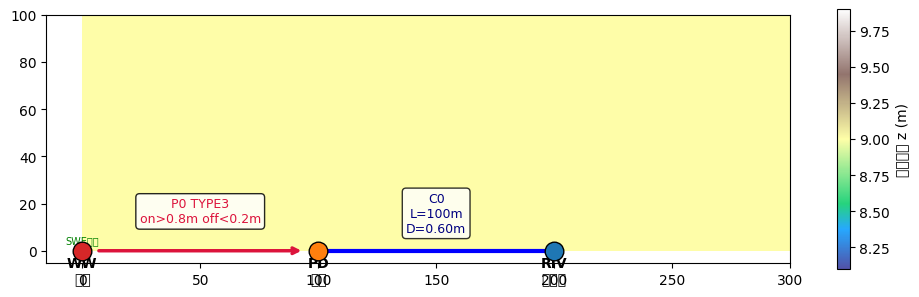

In [51]:
# --- 图1: 研究区 DEM + 排水系统平面布置 ---
fig, ax = plt.subplots(figsize=(12, 4.5))

dx = dem['cellsize']
ny, nx = dem['z'].shape
x_centers = dem['xllcorner'] + (np.arange(nx) + 0.5) * dx
y_centers = dem['yllcorner'] + (np.arange(ny) + 0.5) * dx
X, Y = np.meshgrid(x_centers, y_centers[::-1])  # row0 = north in plot

im = ax.imshow(dem['z'], origin='upper', extent=[dem['xllcorner'], extent_x, dem['yllcorner'], extent_y],
               cmap='terrain', alpha=0.85, aspect='equal')
cb = fig.colorbar(im, ax=ax, shrink=0.75, label='地面高程 z (m)')

# 管网连线
for c in conduits:
    a, b = node_by_id[c['from']], node_by_id[c['to']]
    ax.plot([a['x'], b['x']], [a['y'], b['y']], 'b-', lw=3, solid_capstyle='round', zorder=3,
            label='CONDUIT' if c['id'] == 0 else None)
    mid_x, mid_y = (a['x'] + b['x']) / 2, (a['y'] + b['y']) / 2
    ax.text(mid_x, mid_y + 8, f"C{c['id']}\nL={c['length']:.0f}m\nD={c['diam']:.2f}m",
            ha='center', fontsize=9, color='navy', bbox=dict(boxstyle='round', fc='white', alpha=0.8))

for p in pumps:
    a, b = node_by_id[p['from']], node_by_id[p['to']]
    ax.annotate('', xy=(b['x'], b['y']), xytext=(a['x'], a['y']),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=2.5, shrinkA=12, shrinkB=12))
    mid_x, mid_y = (a['x'] + b['x']) / 2, (a['y'] + b['y']) / 2 + 12
    ax.text(mid_x, mid_y, f"P{p['id']} TYPE3\non>{p['y_on']}m off<{p['y_off']}m",
            ha='center', fontsize=9, color='crimson', bbox=dict(boxstyle='round', fc='white', alpha=0.85))
if not pumps:
    ax.text(50, 12, '本图 inp 无 [PUMPS]\n见 no_pump/Drainage.inp', ha='center', fontsize=9, color='gray')

# 节点与耦合 footprint
junc_size = float(drain_params.get('junctionSize', 0.6))
labels = NODE_LABELS
colors = {0: '#d62728', 1: '#ff7f0e', 2: '#1f77b4'}
for n in nodes:
    ax.scatter(n['x'], n['y'], s=180, c=colors.get(n['id'], 'gray'), edgecolors='k', zorder=5)
    ax.text(n['x'], n['y'] - 14, labels.get(n['id'], f"N{n['id']}"), ha='center', fontsize=10, fontweight='bold')
    if n['type'] == 'junction' and n['sealed'] == 0:
        half = junc_size / 2
        ax.add_patch(Rectangle((n['x'] - half, n['y'] - half), junc_size, junc_size,
                               fill=False, ec='lime', lw=1.5, ls='--', zorder=4))
        ax.text(n['x'], n['y'] + half + 3, 'SWE耦合', ha='center', fontsize=7, color='green')

for of in outfalls:
    ax.axhline(of['stage'], color='none')  # placeholder for legend only

ax.set_xlim(dem['xllcorner'] - 10, extent_x + 10)
ax.set_ylim(-25, extent_y + 15)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('pump_river_minimal — 研究区 DEM 与排水系统平面布置')
ax.grid(True, alpha=0.3)

legend_elems = [
    Line2D([0], [0], color='b', lw=3, label='管道 CONDUIT'),
    Line2D([0], [0], color='crimson', lw=2.5, label='泵站 PUMP (有向)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='节点'),
    Line2D([0], [0], color='lime', ls='--', label=f'地表耦合范围 (~{junc_size} m)'),
]
ax.legend(handles=legend_elems, loc='upper right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_29749/2750553485.py:57: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/2750553485.py:57: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/2750553485.py:57: UserWarning: Glyph 32437 (\N{CJK UNIFIED IDEOGRAPH-7EB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/2750553485.py:57: UserWarning: Glyph 21078 (\N{CJK UNIFIED IDEOGRAPH-5256}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/2750553485.py:57: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/2750553485.py:57: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/2750553485.py:57: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAP

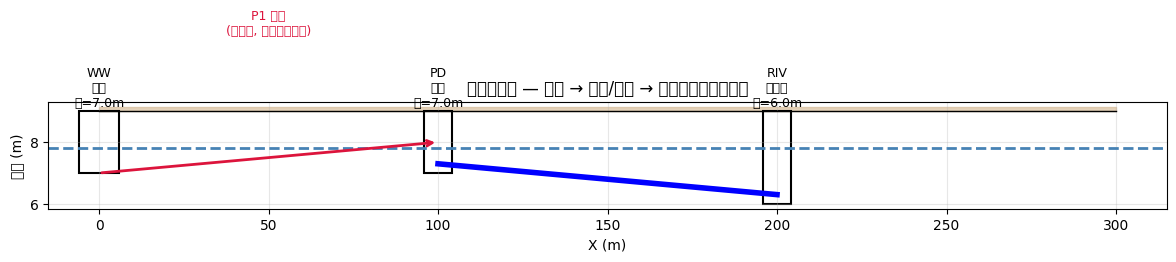

In [52]:
# --- 图2: 沿 X 轴纵剖面（y=0 附近）---
ground_z = float(dem['z'][0, 0])
riv = node_by_id[2]
if river_stage:
    t_plot = np.linspace(0, float(params.get('simLength', 3600)), 200)
    z_river = [river_stage_at(t, river_stage) for t in t_plot]
    river_label = f'时变河位 {min(z_river):.1f}–{max(z_river):.1f} m'
    river_stage_ref = max(z_river)
else:
    river_stage_ref = outfalls[0].get('stage') or riv['invert']
    river_label = f'河位 {river_stage_ref} m'

xs = [n['x'] for n in sorted(nodes, key=lambda n: n['x'])]
fig, ax = plt.subplots(figsize=(12, 4))

# 地面
ax.fill_between([dem['xllcorner'], extent_x], ground_z, ground_z + 0.15, color='tan', alpha=0.6, label='地面 z=9 m')
ax.plot([dem['xllcorner'], extent_x], [ground_z, ground_z], 'k-', lw=1)

# 河位（剖面图画高潮位示意）
ax.axhline(river_stage_ref, color='steelblue', ls='--', lw=2, label=river_label)

for n in nodes:
    w = 12 if n['id'] == 0 else 8
    bottom = n['invert']
    top = bottom + n['max_depth']
    water = bottom + n['init_depth']
    ax.add_patch(Rectangle((n['x'] - w/2, bottom), w, top - bottom, fill=False, ec='k', lw=1.5))
    if n['init_depth'] > 0:
        ax.add_patch(Rectangle((n['x'] - w/2 + 1, bottom), w - 2, n['init_depth'], fc='cyan', alpha=0.5, ec='none'))
    ax.text(n['x'], top + 0.15, f"{NODE_LABELS.get(n['id'], n['id'])}\n底={bottom}m", ha='center', fontsize=9)

# 管道示意（PD→RIV 下坡）
c = conduits[0]
a, b = node_by_id[c['from']], node_by_id[c['to']]
pipe_y = a['invert'] + 0.3
ax.plot([a['x'], b['x']], [pipe_y, b['invert'] + 0.3], 'b-', lw=4, label='C1 管中心线(示意)')

# 泵站扬升 (仅有泵 inp)
if pumps:
    ww, pd = node_by_id[0], node_by_id[1]
    ax.annotate('', xy=(pd['x'], pd['invert'] + 1), xytext=(ww['x'], ww['invert'] + ww['init_depth']),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
    ax.text((ww['x'] + pd['x'])/2, 11.5, 'P1 泵站\n(非管道, 曲线控制流量)', ha='center', color='crimson', fontsize=9)
elif any(c['from'] == 0 and c['to'] == 1 for c in conduits):
    ww, pd = node_by_id[0], node_by_id[1]
    ax.plot([ww['x'], pd['x']], [ww['invert'] + 0.3, pd['invert'] + 0.3], 'g-', lw=3)
    ax.text((ww['x'] + pd['x'])/2, 11.2, 'C0 管道 WW→PD\n(可双向/倒灌)', ha='center', color='green', fontsize=9)

ax.set_xlim(-15, extent_x + 15)
# ax.set_ylim(7.5, 15.5)
ax.set_xlabel('X (m)')
ax.set_ylabel('高程 (m)')
ax.set_title('纵剖面示意 — 湿井 → 泵站/管道 → 管排入时变河位出口')
# ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# --- 图3: 输入文件与组件对照表 ---
import pandas as pd

rows = []
for n in nodes:
    rows.append({
        '组件': NODE_LABELS.get(n['id'], f"Node {n['id']}").replace('\n', ' '),
        'inp文件': 'Drainage.inp [JUNCTIONS]',
        'X(m)': n['x'], 'Y(m)': n['y'],
        '底高程(m)': n['invert'], '初水深(m)': n['init_depth'],
        '类型': n['type'], 'sealed': n['sealed'],
    })
for p in pumps:
    rows.append({'组件': f"P{p['id']} 泵站", 'inp文件': 'Drainage.inp [PUMPS]',
                 'from→to': f"{p['from']}→{p['to']}", '启泵(m)': p['y_on'], '停泵(m)': p['y_off']})
for c in conduits:
    rows.append({'组件': f"C{c['id']} 管道", 'inp文件': 'Drainage.inp [CONDUITS]',
                 'from→to': f"{c['from']}→{c['to']}", 'L(m)': c['length'], 'D(m)': c['diam']})

df = pd.DataFrame(rows)
display(df)

print('\n当前算例目录最小输入集:')
for f in sorted(CASE_DIR.glob('*')):
    if f.is_file() and f.suffix != '.ipynb':
        print(' ', f.name)

,组件,inp文件,X(m),Y(m),底高程(m),初水深(m),类型,sealed,from→to,启泵(m),停泵(m),L(m),D(m)
0,WW 湿井,Drainage.inp [JUNCTIONS],0.0,0.0,7.0,0.0,junction,0.0,NaN,NaN,NaN,NaN,NaN
1,PD 泵后,Drainage.inp [JUNCTIONS],100.0,0.0,7.0,0.0,junction,1.0,NaN,NaN,NaN,NaN,NaN
2,RIV 河出口,Drainage.inp [JUNCTIONS],200.0,0.0,6.0,0.0,outlet,0.0,NaN,NaN,NaN,NaN,NaN
3,P0 泵站,Drainage.inp [PUMPS],NaN,NaN,NaN,NaN,NaN,NaN,0→1,0.8,0.2,NaN,NaN
4,C0 管道,Drainage.inp [CONDUITS],NaN,NaN,NaN,NaN,NaN,NaN,1→2,NaN,NaN,100.0,0.6



当前算例目录最小输入集:
  Drainage-parameter.input
  Drainage.inp
  Norainfall.input
  dem.input
  parameters.input
  run.sh
  run_compare.sh
  sw.input


## 时变河位与节点水深对比（有泵 vs 无泵）

需先运行 `./run_compare.sh`（或分别生成 `output_with_pump/`、`output_no_pump/` 下的 `DrainageTimeSeries.out`）。

/tmp/ipykernel_29749/3177551804.py:20: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/3177551804.py:20: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/3177551804.py:20: UserWarning: Glyph 27827 (\N{CJK UNIFIED IDEOGRAPH-6CB3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/3177551804.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/3177551804.py:20: UserWarning: Glyph 32477 (\N{CJK UNIFIED IDEOGRAPH-7EDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/3177551804.py:20: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/3177551804.py:20: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAP

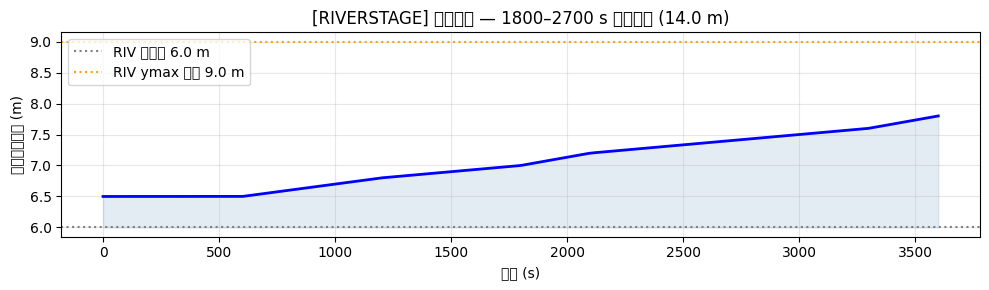

In [54]:
# --- 图4:  prescribed 河位过程 ---
OUT_PUMP = CASE_DIR / 'output_with_pump' / 'DrainageTimeSeries.out'
OUT_NOPUMP = CASE_DIR / 'output_no_pump' / 'DrainageTimeSeries.out'

sim_len = float(params.get('simLength', 3600))
t_river = np.linspace(0, sim_len, 300)
z_river = [river_stage_at(t, river_stage) for t in t_river]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_river, z_river, 'b-', lw=2)
ax.axhline(node_by_id[2]['invert'], color='gray', ls=':', label=f"RIV 底高程 {node_by_id[2]['invert']} m")
ax.axhline(node_by_id[2]['invert'] + node_by_id[2]['max_depth'], color='orange', ls=':',
           label=f"RIV ymax 水面 {node_by_id[2]['invert'] + node_by_id[2]['max_depth']} m")
ax.fill_between(t_river, z_river, node_by_id[2]['invert'], alpha=0.15, color='steelblue')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('河位绝对高程 (m)')
ax.set_title('[RIVERSTAGE] 时变河位 — 1800–2700 s 极端顶托 (14.0 m)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_29749/225985274.py:24: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:24: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:24: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:24: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:24: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:24: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:24: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}

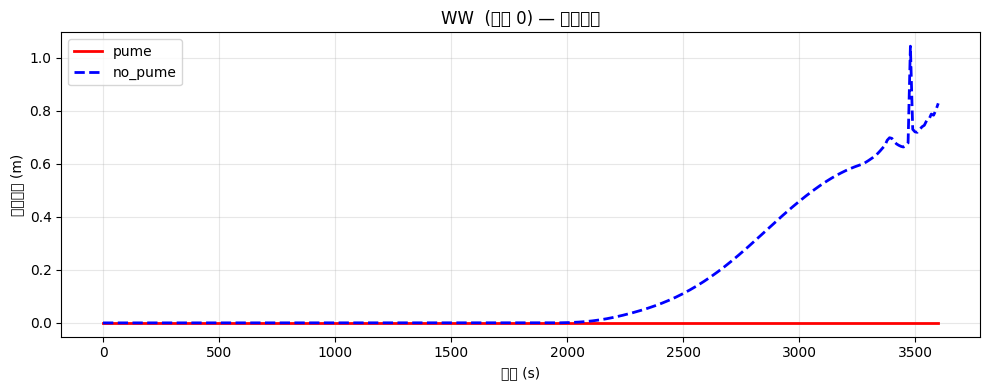

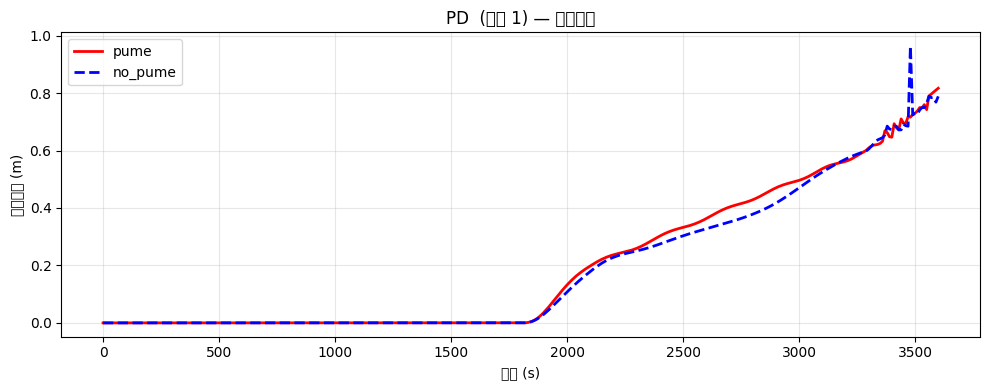

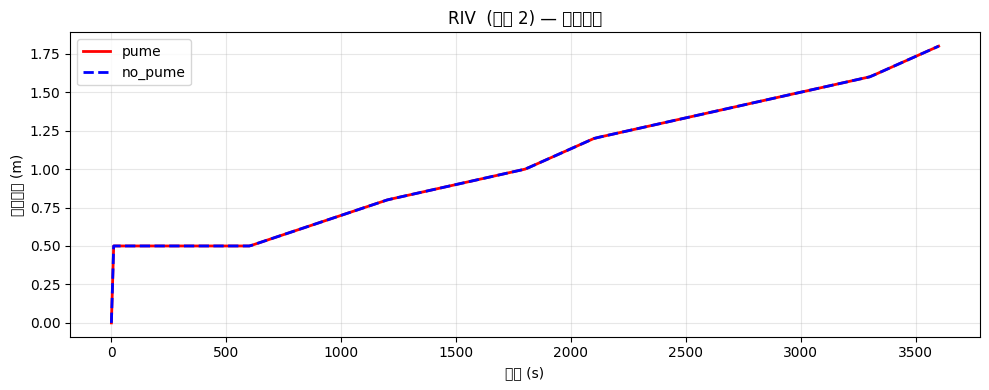

/tmp/ipykernel_29749/225985274.py:40: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:40: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:40: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:40: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:40: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:40: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29749/225985274.py:40: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}

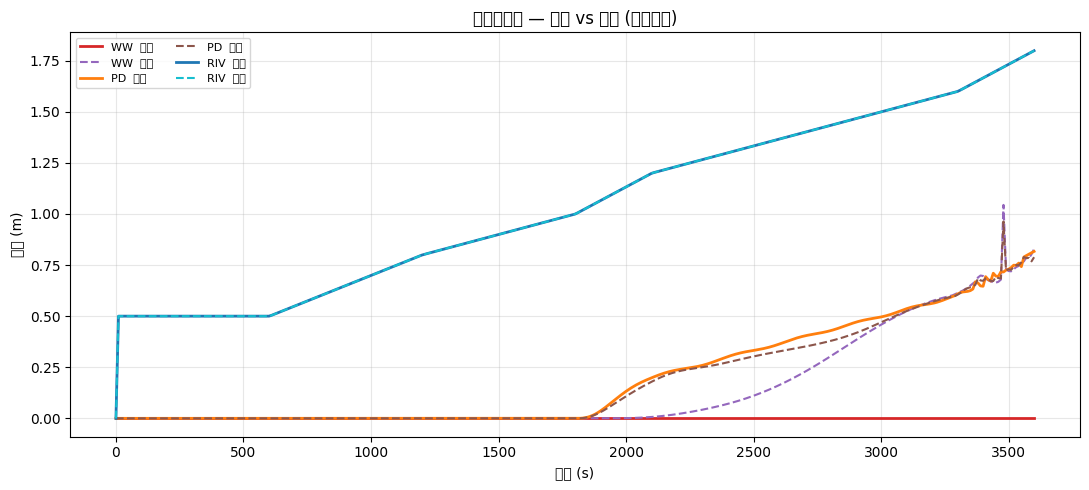

In [55]:
# --- 图5–7: WW / PD / RIV 水深随时间 (有泵 vs 无泵) ---
df_pump = read_drainage_timeseries(OUT_PUMP)
df_nopump = read_drainage_timeseries(OUT_NOPUMP)

if df_pump is None or df_nopump is None:
    missing = [p for p, d in [('pume', df_pump), ('no_pume', df_nopump)] if d is None]
    raise FileNotFoundError(
        f"缺少 DrainageTimeSeries.out ({', '.join(missing)}). 请先运行: ./run_compare.sh"
    )

depth_cols = {0: 'NODE_0_depth[m]', 1: 'NODE_1_depth[m]', 2: 'NODE_2_depth[m]'}
node_names = {0: 'WW ', 1: 'PD ', 2: 'RIV '}

for nid, title in node_names.items():
    col = depth_cols[nid]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df_pump['Time'], df_pump[col], 'r-', lw=2, label='pume')
    ax.plot(df_nopump['Time'], df_nopump[col], 'b--', lw=2, label='no_pume')
    ax.set_xlabel('时间 (s)')
    ax.set_ylabel('节点水深 (m)')
    ax.set_title(f'{title} (节点 {nid}) — 水深对比')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 三节点同图
fig, ax = plt.subplots(figsize=(11, 5))
colors_p = ['#d62728', '#ff7f0e', '#1f77b4']
colors_n = ['#9467bd', '#8c564b', '#17becf']
for nid, name in node_names.items():
    col = depth_cols[nid]
    ax.plot(df_pump['Time'], df_pump[col], color=colors_p[nid], lw=2, label=f'{name} 有泵')
    ax.plot(df_nopump['Time'], df_nopump[col], color=colors_n[nid], ls='--', lw=1.5, label=f'{name} 无泵')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('水深 (m)')
ax.set_title('三节点水深 — 有泵 vs 无泵 (时变河位)')
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'node_names' is not defined

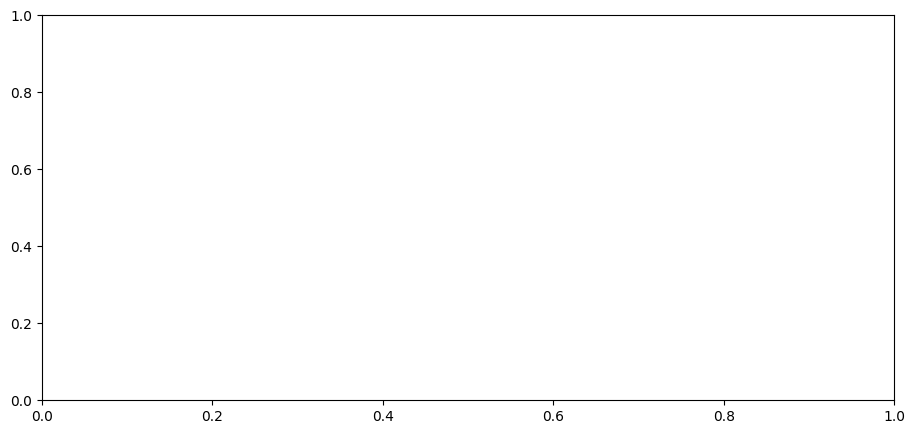

In [7]:
# --- 图8: 高潮段 (1500–2800 s) 放大 ---
t0, t1 = 1500, 2800
fig, ax = plt.subplots(figsize=(11, 5))
for nid, name in node_names.items():
    col = depth_cols[nid]
    m1 = (df_pump['Time'] >= t0) & (df_pump['Time'] <= t1)
    m2 = (df_nopump['Time'] >= t0) & (df_nopump['Time'] <= t1)
    ax.plot(df_pump.loc[m1, 'Time'], df_pump.loc[m1, col], lw=2, label=f'{name} 有泵')
    ax.plot(df_nopump.loc[m2, 'Time'], df_nopump.loc[m2, col], ls='--', lw=1.5, label=f'{name} 无泵')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('水深 (m)')
ax.set_title('极端顶托时段放大 — 无泵时 WW/PD 更易受 C1/C0 倒灌影响')
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 简要数值对比 (末期高潮附近)
t_peak = 2100
for label, df in [('有泵', df_pump), ('无泵', df_nopump)]:
    row = df.iloc[(df['Time'] - t_peak).abs().argmin()]
    print(f"\n{label} @ t≈{t_peak}s:")
    for nid, name in node_names.items():
        print(f"  {name}: {row[depth_cols[nid]]:.4f} m")